In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,

    confusion_matrix,
    classification_report,

    roc_curve
)

In [2]:
df = pd.read_csv(
    "../data/deals_transformados.csv"
)

df.head()

,titulo,precio_oferta,precio_normal,ahorro_porcentaje,store_id,rating_steam,steam_rating_count,metacritic,deal_rating,steam_app_id,release_date,fecha_extraccion,ahorro_real,precio_relacion,categoria_descuento,popularidad,descuento_calidad,tipo_precio,antiguedad_dias,antiguedad_anios
0,Valdis Story Abyssal City,14.99,14.99,0.00,2,82.0,1648,83.0,0.0,252030.0,2013-09-08,2026-05-13 20:22:13.538415,0.00,1.00,NaN,Bueno,0.00,Normal,4630,12.7
1,Mr. Robot,14.99,14.99,0.00,2,82.0,95,83.0,0.0,20710.0,2007-01-10,2026-05-13 20:22:13.538410,0.00,1.00,NaN,Bueno,0.00,Normal,7063,19.4
2,Independence War 2 - Edge of Chaos,5.99,5.99,0.00,2,75.0,88,83.0,0.0,359630.0,2001-08-22,2026-05-13 20:22:13.538404,0.00,1.00,NaN,Bueno,0.00,Barato,9030,24.7
3,Kumitantei: Old-School Slaughter,14.99,14.99,0.00,2,89.0,222,84.0,0.0,2759280.0,2026-04-23,2026-05-13 20:22:13.538383,0.00,1.00,NaN,Excelente,0.00,Normal,20,0.1
4,News Tower,18.74,24.99,25.01,2,94.0,2677,84.0,4.6,1649950.0,2025-11-18,2026-05-13 20:22:13.538376,6.25,0.75,Medio,Excelente,2350.94,Normal,176,0.5


In [3]:
df["es_oferta_brutal"] = np.where(

    df["ahorro_porcentaje"] >= 80,
    1,
    0

)

In [4]:
df["es_oferta_brutal"].value_counts()

es_oferta_brutal
0    382
1    250
Name: count, dtype: int64

In [5]:
features = [

    "precio_oferta",
    "precio_normal",
    "rating_steam",
    "metacritic",
    "steam_rating_count",
    "deal_rating",
    "antiguedad_anios"

]

X = df[features]

y = df["es_oferta_brutal"]

In [6]:
X = X.fillna(
    X.median()
)

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
splits = {

    "Split_1_80_20": 0.2,
    "Split_2_70_30": 0.3,
    "Split_3_60_40": 0.4

}


Split_1_80_20

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.73      0.84        77
           1       0.70      1.00      0.83        50

    accuracy                           0.83       127
   macro avg       0.85      0.86      0.83       127
weighted avg       0.88      0.83      0.84       127



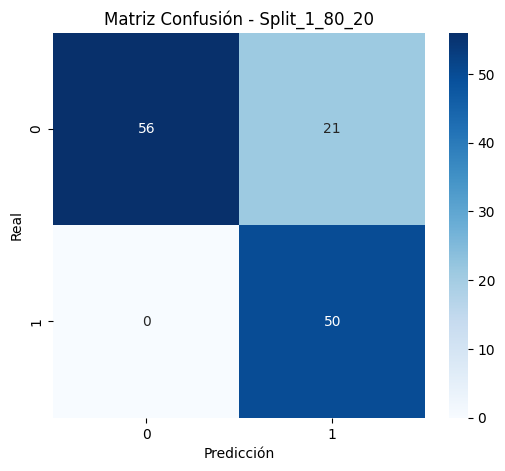

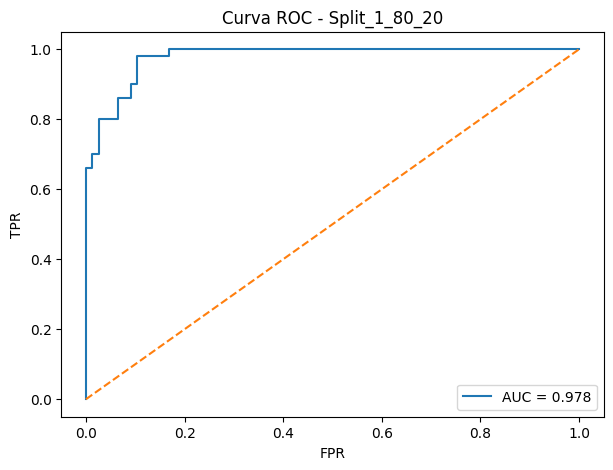


Split_2_70_30

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.77      0.86       115
           1       0.73      0.99      0.84        75

    accuracy                           0.85       190
   macro avg       0.86      0.88      0.85       190
weighted avg       0.89      0.85      0.85       190



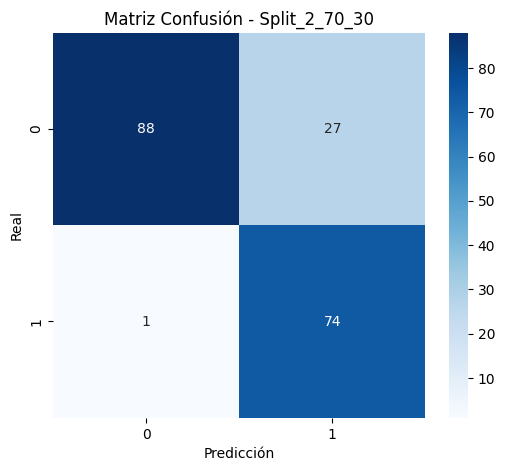

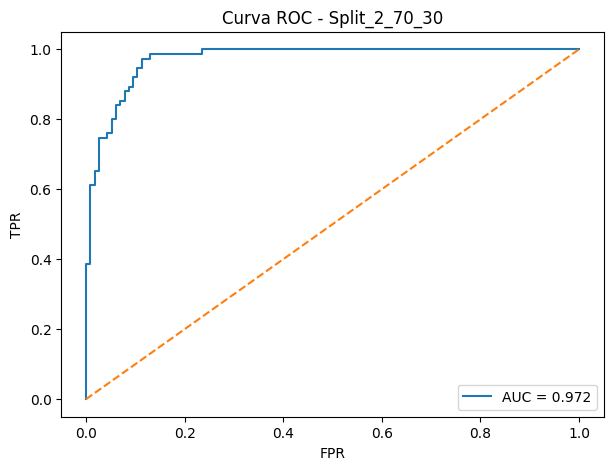


Split_3_60_40

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.78      0.87       153
           1       0.74      0.99      0.85       100

    accuracy                           0.86       253
   macro avg       0.87      0.88      0.86       253
weighted avg       0.89      0.86      0.86       253



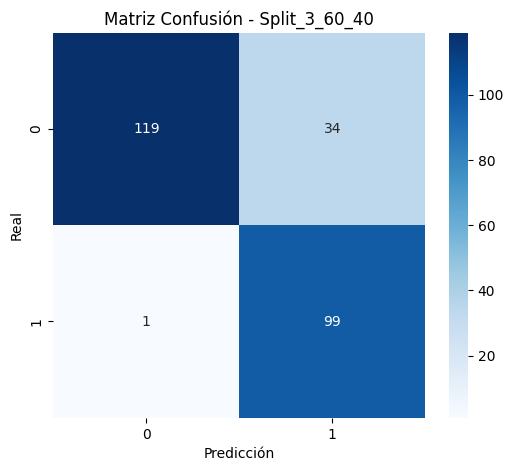

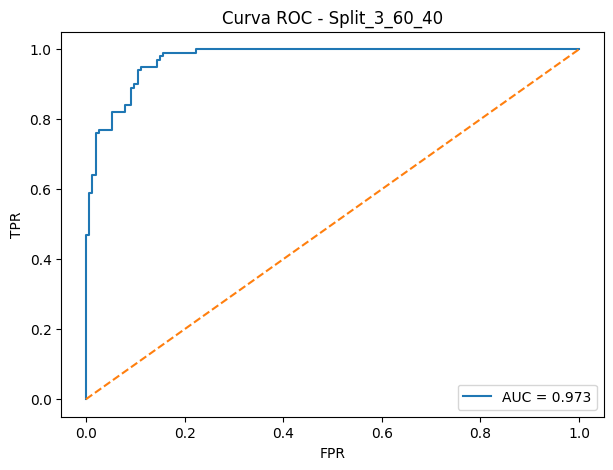

In [9]:
resultados = []

for nombre, test_size in splits.items():

    print(f"\n{'='*60}")
    print(nombre)
    print(f"{'='*60}")

    # -----------------------------------
    # SPLIT
    # -----------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X_scaled,
        y,

        test_size=test_size,

        random_state=42,

        stratify=y

    )

    # -----------------------------------
    # MODELO
    # -----------------------------------

    modelo = LogisticRegression(

        class_weight='balanced',

        random_state=42,

        max_iter=1000

    )

    modelo.fit(
        X_train,
        y_train
    )

    # -----------------------------------
    # PREDICCIONES
    # -----------------------------------

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    # -----------------------------------
    # MÉTRICAS
    # -----------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    resultados.append({

        "Split": nombre,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc

    })

    # -----------------------------------
    # REPORTE
    # -----------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # -----------------------------------
    # MATRIZ DE CONFUSIÓN
    # -----------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,
        fmt='d',
        cmap='Blues'

    )

    plt.title(
        f"Matriz Confusión - {nombre}"
    )

    plt.xlabel("Predicción")
    plt.ylabel("Real")

    plt.show()

    # -----------------------------------
    # CURVA ROC
    # -----------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.3f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.title(
        f"Curva ROC - {nombre}"
    )

    plt.xlabel("FPR")
    plt.ylabel("TPR")

    plt.legend()

    plt.show()

In [10]:
df_resultados = pd.DataFrame(
    resultados
)

df_resultados

,Split,Accuracy,Precision,Recall,F1,ROC_AUC
0,Split_1_80_20,0.834646,0.704225,1.000000,0.826446,0.977662
1,Split_2_70_30,0.852632,0.732673,0.986667,0.840909,0.972406
2,Split_3_60_40,0.861660,0.744361,0.990000,0.849785,0.972745


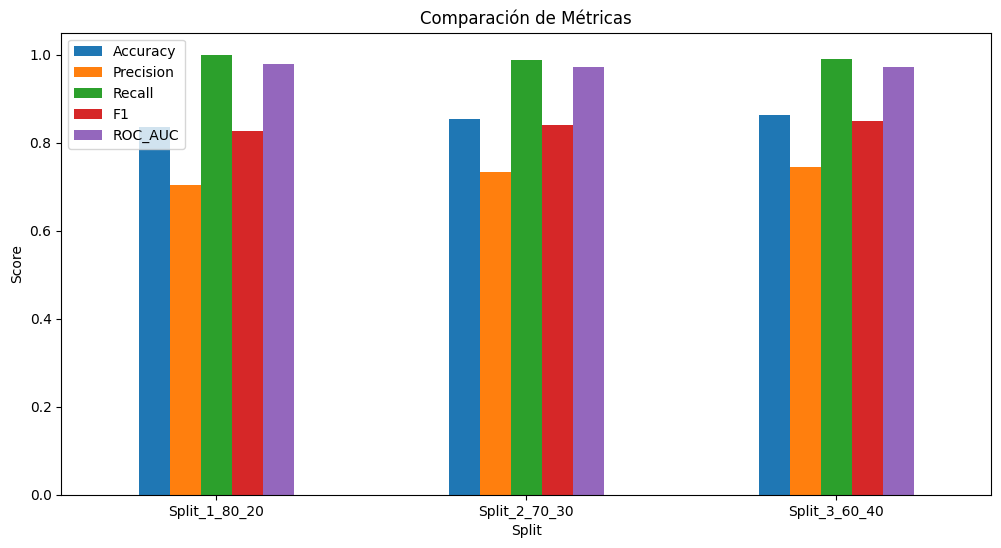

In [11]:
df_resultados.set_index("Split")[

    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]

].plot(

    kind='bar',

    figsize=(12,6)

)

plt.title(
    "Comparación de Métricas"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [12]:
coeficientes = pd.DataFrame({

    "Variable": features,

    "Coeficiente": modelo.coef_[0]

})

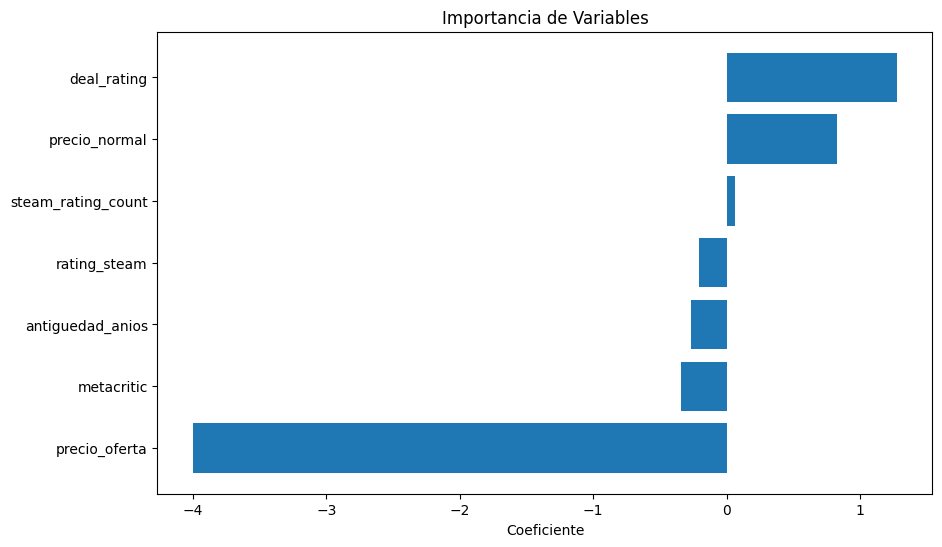

In [13]:
coeficientes = coeficientes.sort_values(
    by="Coeficiente"
)

plt.figure(figsize=(10,6))

plt.barh(

    coeficientes["Variable"],
    coeficientes["Coeficiente"]

)

plt.title(
    "Importancia de Variables"
)

plt.xlabel("Coeficiente")

plt.show()